# Hierarchical Multi-Agent System


 **Structure**:

**CEO (top level)**

* **Research Team Leader**

  *   Data Researcher
  *   Market Researcher

* **Writing Team Leader**


Technical Writer

  *   Technical Write
  *   Summary Writer

In [ ]:
!pip install langchain-google-genai langchain_tavily langchain_community langchain_groq langchain_tavily

In [3]:
import os
from typing import TypedDict, Annotated, List, Literal
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, END
from langgraph.graph.message import MessagesState
from langgraph.prebuilt import create_react_agent, ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langchain_tavily import TavilySearch
from langchain_core.prompts import ChatPromptTemplate


/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [4]:
from typing import TypedDict, Annotated, List, Literal, Dict, Any
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
import random
from datetime import datetime

In [ ]:
os.environ['GOOGLE_API_KEY']="xxxxxxx"
os.environ['TAVILY_API_KEY']="xxxxxxx"

In [67]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash",
                             temperature=0.2)

In [68]:
# State Definition

class TeamState(MessagesState):
    """State for the multi-agent system"""
    next_agent: str = ""
    data_research: str = ""
    market_research: str = ""
    technical_writing: str = ""
    final_report: str = ""
    task_complete: bool = False
    current_task: str = ""

In [69]:
def create_ceo_chain():
    """Creates the CEO decision chain"""

    ceo_prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            """
You are the CEO of a multi-agent AI company.

Your responsibility is to manage and delegate tasks to the correct team leader or agent.

Team Structure:

1. Research Team Leader
   - Data Researcher
   - Market Researcher

2. Writing Team Leader
   - Technical Writer
   - Summary Writer

Your job:
- Analyze the user's request and current workflow state.
- Decide which team leader or agent should act next.
- Ensure work flows logically from research -> writing.
- If the entire task is completed, respond with 'DONE'.

Current workflow state:
- Has data research: {has_data_research}
- Has market research: {has_market_research}
- Has technical writing: {has_technical_writing}
- Has summary: {has_summary}

Available agents:
- research_team_leader
- data_researcher
- market_researcher
- writing_team_leader
- technical_writer
- summary_writer

Rules:
- Use research agents when information gathering is needed.
- Use writing agents when content creation or summarization is needed.
- Prefer team leaders for coordination-level decisions.
- Respond ONLY with one of the agent names above or 'DONE'.
"""
        ),
        ("human", "{task}")
    ])

    return ceo_prompt | llm

In [70]:

def ceo_agent(state:TeamState)-> Dict:
  """CEO decides next agent using Google Gemini"""
  messages = state['messages']
  task = messages[-1].content if messages else "No task"

  has_data_research = bool(state.get("data_research", ""))
  has_market_research = bool(state.get("market_research", ""))
  has_technical_writing = bool(state.get("technical_writing", ""))
  has_summary = bool(state.get("final_report", "")) # Renamed from has_report


  chain = create_ceo_chain()
  decision = chain.invoke({
        "task": task,
        "has_data_research": has_data_research,
        "has_market_research": has_market_research,
        "has_technical_writing": has_technical_writing,
        "has_summary": has_summary # Renamed from has_report
    })

  decision_text = decision.content.strip().lower()
  print(decision_text)

  # Determine next agent based on workflow progress

  if "done" in decision_text or has_summary:
      next_agent = "end"
      ceo_msg = "✅ CEO: All departments have completed their work successfully."

  # RESEARCH PHASE
  elif (
      "research_team_leader" in decision_text
      or (not has_data_research and not has_market_research)
  ):
      next_agent = "research_team_leader"
      ceo_msg = (
          "📋 CEO: Research phase initiated. "
          "Assigning task to Research Team Leader..."
      )

  elif (
      "data_researcher" in decision_text
      or not has_data_research
  ):
      next_agent = "data_researcher"
      ceo_msg = (
          "📊 Research Team Leader: "
          "Collecting statistical and technical research data..."
      )

  elif (
      "market_researcher" in decision_text
      or not has_market_research
  ):
      next_agent = "market_researcher"
      ceo_msg = (
          "📈 Research Team Leader: "
          "Performing market and competitor analysis..."
      )

  # WRITING PHASE
  elif (
      "writing_team_leader" in decision_text
      or (
          has_data_research
          and has_market_research
          and not has_technical_writing
      )
  ):
      next_agent = "writing_team_leader"
      ceo_msg = (
          "✍️ CEO: Research completed successfully. "
          "Assigning task to Writing Team Leader..."
      )

  elif (
      "technical_writer" in decision_text
      or (
          has_data_research
          and has_market_research
          and not has_technical_writing
      )
  ):
      next_agent = "technical_writer"
      ceo_msg = (
          "📝 Writing Team Leader: "
          "Creating detailed technical documentation and report..."
      )

  elif (
      "summary_writer" in decision_text
      or (
          has_technical_writing
          and not has_summary
      )
  ):
      next_agent = "summary_writer"
      ceo_msg = (
          "📄 Writing Team Leader: "
          "Generating executive summary and concise insights..."
      )

  # FALLBACK
  else:
      next_agent = "end"
      ceo_msg = (
          "✅ CEO: Workflow appears complete. "
          "No additional actions required."
      )
  return {
        "messages": [AIMessage(content=ceo_msg)],
        "next_agent": next_agent,
        "current_task": task
    }

In [71]:
def research_team_leader(state: TeamState) -> Dict:
    """Research Team Leader Node"""

    messages = state["messages"]
    task = state.get("current_task", "")

    has_data_research = bool(state.get("data_research", ""))
    has_market_research = bool(state.get("market_research", ""))

    # Decide which research agent should work next

    # No research done yet
    if not has_data_research and not has_market_research:

        next_agent = "data_researcher"

        research_leader_msg = (
            "📋 Research Team Leader: "
            "Starting research workflow. "
            "Assigning task to Data Researcher for "
            "technical statistics and factual data collection."
        )

    # Data research completed → market research next
    elif has_data_research and not has_market_research:

        next_agent = "market_researcher"

        research_leader_msg = (
            "📈 Research Team Leader: "
            "Technical data research completed. "
            "Assigning task to Market Researcher for "
            "market trends, competitors, and industry analysis."
        )

    # Both research tasks completed
    elif has_data_research and has_market_research:

        next_agent = "ceo"

        research_leader_msg = (
            "✅ Research Team Leader: "
            "All research activities completed successfully. "
            "Sending results back to CEO for next phase."
        )

    # Fallback safety
    else:

        next_agent = "ceo"

        research_leader_msg = (
            "⚠️ Research Team Leader: "
            "Unexpected workflow state detected. "
            "Returning control to CEO."
        )

    return {
        "messages": messages + [AIMessage(content=research_leader_msg)],
        "next_agent": next_agent,
        "current_task": task
    }

In [ ]:
!pip install -U langchain langchain-community langchain-text-splitters faiss-cpu sentence-transformers pypdf

In [22]:
# RAG
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
embeddings = HuggingFaceEmbeddings()

loader = PyPDFLoader("/content/data.pdf")
docs = loader.load()

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap  = 200
)
chunked_docs = text_splitter.split_documents(docs)

db = FAISS.from_documents(chunked_docs,
                          embedding=embeddings)

/tmp/ipykernel_4394/3202367215.py:6: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings()
/tmp/ipykernel_4394/3202367215.py:6: LangChainDeprecationWarning: Default values for HuggingFaceEmbeddings.model_name were deprecated in LangChain 0.2.16 and will be removed in 0.4.0. Explicitly pass a model_name to the HuggingFaceEmbeddings constructor instead.
  embeddings = HuggingFaceEmbeddings()
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/to

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [72]:
# DATA RESEARCHER NODE


def data_researcher(state: TeamState) -> Dict:
    """Data Researcher Node with RAG Retrieval"""

    messages = state["messages"]
    task = state.get("current_task", "")

    try:

        # VECTOR RETRIEVAL

        retrieved_docs = db.similarity_search(
            query=task,
            k=5
        )

        retrieved_context = "\n\n".join([
            doc.page_content
            for doc in retrieved_docs
        ])

        # RESEARCH PROMPT

        research_prompt = ChatPromptTemplate.from_template("""
You are an expert Data Researcher AI agent.

Your responsibilities:
- Extract technical insights
- Gather statistical information
- Identify benchmarks
- Analyze structured data
- Produce factual research findings

User Task:
{task}

Retrieved Knowledge Base Context:
{context}

Generate a detailed technical research report with:
1. Key Statistics
2. Technical Benchmarks
3. Important Numerical Insights
4. Data-driven Findings
5. Industry Metrics

Keep the response professional and structured.
""")

        chain = research_prompt | llm

        response = chain.invoke({
            "task": task,
            "context": retrieved_context
        })

        research_result = response.content

        researcher_msg = (
            "📊 Data Researcher: "
            "RAG-based technical and statistical research completed successfully."
        )

    except Exception as e:

        research_result = f"Error during data research: {str(e)}"

        researcher_msg = (
            "⚠️ Data Researcher: "
            "Encountered an issue during research process."
        )

    return {
        "messages": messages + [AIMessage(content=researcher_msg)],

        # Store research output
        "data_research": research_result,

        # Return to team leader
        "next_agent": "research_team_leader",

        "current_task": task
    }



# MARKET RESEARCHER NODE

def market_researcher(state: TeamState) -> Dict:
    """Market Researcher Node with Web Search"""

    messages = state["messages"]
    task = state.get("current_task", "")

    try:

        # WEB SEARCH

        search = TavilySearchResults(max_results=5)

        search_results = search.invoke(task)

        web_context = "\n\n".join([
            str(result)
            for result in search_results
        ])


        # MARKET RESEARCH PROMPT

        market_prompt = ChatPromptTemplate.from_template("""
You are an expert Market Research Analyst AI agent.

Your responsibilities:
- Analyze market trends
- Identify competitors
- Study customer demand
- Discover business opportunities
- Generate strategic insights

User Task:
{task}

Web Search Results:
{context}

Generate a professional market research report including:
1. Market Trends
2. Competitor Analysis
3. Industry Opportunities
4. Customer Demand Insights
5. Strategic Recommendations

Keep the report professional and actionable.
""")

        chain = market_prompt | llm

        response = chain.invoke({
            "task": task,
            "context": web_context
        })

        market_research_result = response.content

        researcher_msg = (
            "📈 Market Researcher: "
            "Web-based market and competitor research completed successfully."
        )

    except Exception as e:

        market_research_result = f"Error during market research: {str(e)}"

        researcher_msg = (
            "⚠️ Market Researcher: "
            "Encountered an issue during market research."
        )

    return {
        "messages": messages + [AIMessage(content=researcher_msg)],

        # Store research output
        "market_research": market_research_result,

        # Return to team leader
        "next_agent": "research_team_leader",

        "current_task": task
    }

In [73]:
# WRITING TEAM LEADER NODE

def writing_team_leader(state: TeamState) -> Dict:
    """Writing Team Leader Node"""

    messages = state["messages"]
    task = state.get("current_task", "")

    # WORKFLOW STATE

    has_data_research = bool(state.get("data_research", ""))
    has_market_research = bool(state.get("market_research", ""))

    has_technical_writing = bool(state.get("technical_writing", ""))
    has_summary = bool(state.get("final_report", ""))

    # WRITING WORKFLOW DECISION LOGIC

    # Safety Check:
    # Writing should not start without research
    if not has_data_research or not has_market_research:

        next_agent = "ceo"

        writing_leader_msg = (
            "⚠️ Writing Team Leader: "
            "Research phase is incomplete. "
            "Returning workflow control to CEO."
        )

    # TECHNICAL WRITING PHASE

    elif (
        has_data_research
        and has_market_research
        and not has_technical_writing
    ):

        next_agent = "technical_writer"

        writing_leader_msg = (
            "📝 Writing Team Leader: "
            "Research inputs verified successfully. "
            "Assigning task to Technical Writer for "
            "detailed report generation."
        )

    # SUMMARY GENERATION PHASE

    elif (
        has_technical_writing
        and not has_summary
    ):

        next_agent = "summary_writer"

        writing_leader_msg = (
            "📄 Writing Team Leader: "
            "Technical report completed successfully. "
            "Assigning task to Summary Writer for "
            "executive summary generation."
        )

    # WRITING COMPLETED

    elif (
        has_technical_writing
        and has_summary
    ):

        next_agent = "ceo"

        writing_leader_msg = (
            "✅ Writing Team Leader: "
            "All writing activities completed successfully. "
            "Returning final outputs to CEO."
        )

    # FALLBACK

    else:

        next_agent = "ceo"

        writing_leader_msg = (
            "⚠️ Writing Team Leader: "
            "Unexpected workflow state detected. "
            "Returning control to CEO."
        )

    return {
        "messages": messages + [AIMessage(content=writing_leader_msg)],

        "next_agent": next_agent,

        "current_task": task
    }

In [74]:
# TECHNICAL WRITER NODE

def technical_writer(state: TeamState) -> Dict:
    """Technical Writer Node"""

    messages = state["messages"]
    task = state.get("current_task", "")

    data_research = state.get("data_research", "")
    market_research = state.get("market_research", "")

    try:

        # TECHNICAL WRITING PROMPT

        technical_writer_prompt = ChatPromptTemplate.from_template("""
You are an expert Technical Writer AI agent.

Your responsibilities:
- Create detailed professional reports
- Convert research into structured documentation
- Present technical and market insights clearly
- Generate well-formatted business reports

User Task:
{task}

Technical & Statistical Research:
{data_research}

Market Research:
{market_research}

Generate a detailed professional report with:

1. Title
2. Executive Introduction
3. Technical Analysis
4. Market Analysis
5. Key Insights
6. Opportunities & Challenges
7. Strategic Recommendations
8. Conclusion

Keep the report:
- Professional
- Detailed
- Well-structured
- Easy to read
""")

        chain = technical_writer_prompt | llm

        response = chain.invoke({
            "task": task,
            "data_research": data_research,
            "market_research": market_research
        })

        technical_document = response.content

        writer_msg = (
            "📝 Technical Writer: "
            "Detailed technical report generated successfully."
        )

    except Exception as e:

        technical_document = (
            f"Error during technical writing process: {str(e)}"
        )

        writer_msg = (
            "⚠️ Technical Writer: "
            "Encountered an issue during report generation."
        )

    return {
        "messages": messages + [AIMessage(content=writer_msg)],

        # Store generated technical report
        "technical_document": technical_document,

        # Return control to Writing Team Leader
        "next_agent": "writing_team_leader",

        "current_task": task
    }



# SUMMARY WRITER NODE

def summary_writer(state: TeamState) -> Dict:
    """Summary Writer Node"""

    messages = state["messages"]
    task = state.get("current_task", "")

    technical_document = state.get("technical_document", "")

    try:

        # SUMMARY GENERATION PROMPT

        summary_prompt = ChatPromptTemplate.from_template("""
You are an expert Executive Summary Writer AI agent.

Your responsibilities:
- Summarize complex reports
- Extract key insights
- Create concise executive summaries
- Highlight important business findings

User Task:
{task}

Technical Report:
{technical_document}

Generate:

1. Executive Summary
2. Key Findings
3. Critical Insights
4. Strategic Recommendations
5. Final Conclusion

Keep the summary:
- Concise
- Professional
- Business-focused
- Easy to understand
""")

        chain = summary_prompt | llm

        response = chain.invoke({
            "task": task,
            "technical_document": technical_document
        })

        final_report = response.content

        writer_msg = (
            "📄 Summary Writer: "
            "Executive summary and final report generated successfully."
        )

    except Exception as e:

        final_report = (
            f"Error during summary generation process: {str(e)}"
        )

        writer_msg = (
            "⚠️ Summary Writer: "
            "Encountered an issue during summary generation."
        )

    return {
        "messages": messages + [AIMessage(content=writer_msg)],

        # Store final summarized report
        "final_report": final_report,

        # Return control to Writing Team Leader
        "next_agent": "writing_team_leader",

        "current_task": task
    }

In [62]:
# # ROUTER FUNCTION

# def router(state: TeamState):
#     """Routes workflow to next agent"""

#     next_agent = state.get("next_agent", "end")

#     if next_agent == "end":
#         return END

#     return next_agent

# # CREATE HIERARCHICAL MULTI-AGENT WORKFLOW

# workflow = StateGraph(TeamState)



# # ADD NODES



# workflow.add_node("ceo", ceo_agent)

# workflow.add_node(
#     "research_team_leader",
#     research_team_leader
# )

# workflow.add_node(
#     "data_researcher",
#     data_researcher
# )

# workflow.add_node(
#     "market_researcher",
#     market_researcher
# )

# workflow.add_node(
#     "writing_team_leader",
#     writing_team_leader
# )

# workflow.add_node(
#     "technical_writer",
#     technical_writer
# )

# workflow.add_node(
#     "summary_writer",
#     summary_writer
# )



# workflow.set_entry_point("ceo")

# workflow.add_conditional_edges(
#     "ceo",
#     router,
#     {
#         "research_team_leader": "research_team_leader",
#         "data_researcher": "data_researcher",
#         "market_researcher": "market_researcher",
#         "writing_team_leader": "writing_team_leader",
#         "technical_writer": "technical_writer",
#         "summary_writer": "summary_writer",
#         END: END
#     }
# )

# workflow.add_conditional_edges(
#     "research_team_leader",
#     router,
#     {
#         "data_researcher": "data_researcher",
#         "market_researcher": "market_researcher",
#         "ceo": "ceo",
#         END: END
#     }
# )

# workflow.add_conditional_edges(
#     "data_researcher",
#     router,
#     {
#         "research_team_leader": "research_team_leader",
#         END: END
#     }
# )

# workflow.add_conditional_edges(
#     "market_researcher",
#     router,
#     {
#         "research_team_leader": "research_team_leader",
#         END: END
#     }
# )

# workflow.add_conditional_edges(
#     "writing_team_leader",
#     router,
#     {
#         "technical_writer": "technical_writer",
#         "summary_writer": "summary_writer",
#         "ceo": "ceo",
#         END: END
#     }
# )

# workflow.add_conditional_edges(
#     "technical_writer",
#     router,
#     {
#         "writing_team_leader": "writing_team_leader",
#         END: END
#     }
# )

# workflow.add_conditional_edges(
#     "summary_writer",
#     router,
#     {
#         "writing_team_leader": "writing_team_leader",
#         END: END
#     }
# )


# # COMPILE GRAPH

# graph = workflow.compile()

In [75]:
# ROUTER
def router(state: TeamState):
    """Dynamic router"""

    next_agent = state.get("next_agent", "end")

    if next_agent == "end":
        return END

    return next_agent

# WORKFLOW

workflow = StateGraph(TeamState)

# ADD NODES

workflow.add_node("ceo", ceo_agent)

workflow.add_node(
    "research_team_leader",
    research_team_leader
)

workflow.add_node(
    "data_researcher",
    data_researcher
)

workflow.add_node(
    "market_researcher",
    market_researcher
)

workflow.add_node(
    "writing_team_leader",
    writing_team_leader
)

workflow.add_node(
    "technical_writer",
    technical_writer
)

workflow.add_node(
    "summary_writer",
    summary_writer
)



# ENTRY POINT

workflow.set_entry_point("ceo")

all_nodes = [
    "ceo",

    "research_team_leader",
    "data_researcher",
    "market_researcher",

    "writing_team_leader",
    "technical_writer",
    "summary_writer"
]

routing_map = {
    "ceo": "ceo",

    "research_team_leader": "research_team_leader",
    "data_researcher": "data_researcher",
    "market_researcher": "market_researcher",

    "writing_team_leader": "writing_team_leader",
    "technical_writer": "technical_writer",
    "summary_writer": "summary_writer",

    END: END
}

for node in all_nodes:

    workflow.add_conditional_edges(
        node,
        router,
        routing_map
    )

graph = workflow.compile()

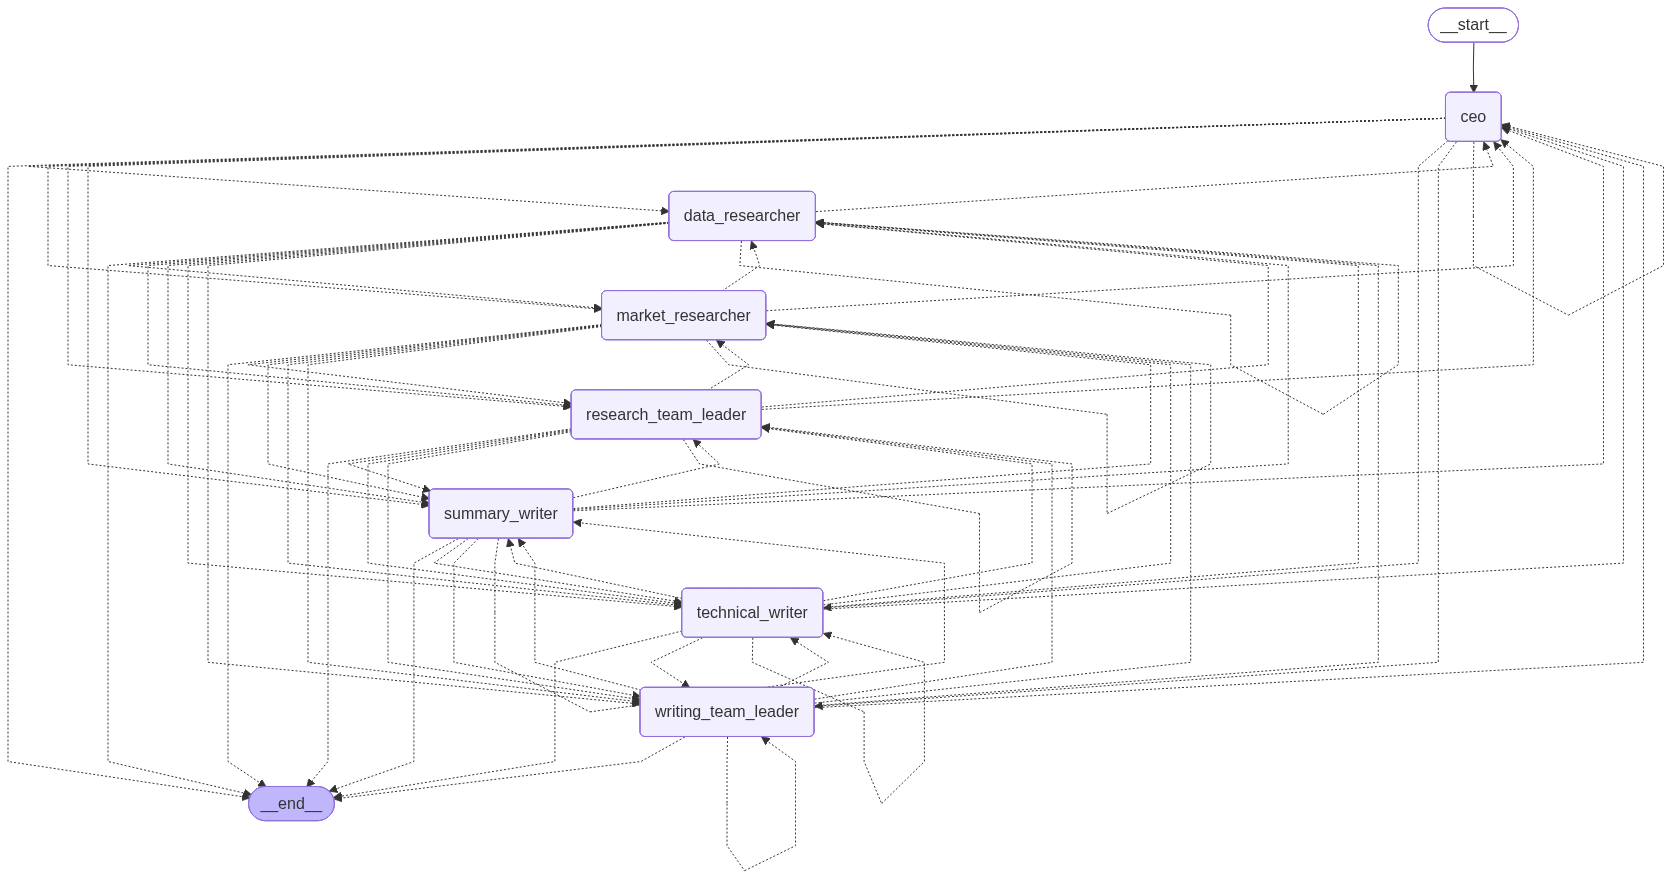

In [ ]:
graph

In [ ]:
response = graph.invoke({
    "messages": [HumanMessage(content="Research the future of autonomous AI agents")]
})
print(response) #its taking a while because its doing web search and RAG retrieval